# Pearson Correlation Coefficient: GDP vs Betweenness Centrality

This notebook calculates the Pearson correlation coefficient between GDP (gdp_regional_10k) and betweenness centrality for each year.

In [10]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [11]:
# Load the data
network_metrics = pd.read_csv('network_metrics_nodes.csv')
econ_data = pd.read_csv('econ_data_en.csv')

print(f"Network metrics shape: {network_metrics.shape}")
print(f"Economic data shape: {econ_data.shape}")
print(f"\nNetwork metrics columns: {network_metrics.columns.tolist()}")
print(f"\nEconomic data columns: {econ_data.columns.tolist()[:10]}...")  # First 10 columns

C:\Users\jmanu\AppData\Local\Temp\ipykernel_45856\2973204131.py:2: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  network_metrics = pd.read_csv('network_metrics_nodes.csv')


Network metrics shape: (71690, 21)
Economic data shape: (64992, 81)

Network metrics columns: ['granularity', 'years', 'year', 'node_id', 'degree', 'degree_unweighted', 'clustering', 'local_efficiency', 'betweenness', 'closeness', 'eigenvector', 'pagerank', 'radiality', 'community', 'participation_coefficient', 'within_module_degree', 'hub_type', 'is_gateway', 'is_provincial', 'is_connector', 'in_lcc']

Economic data columns: ['Unnamed: 0', 'year', 'province', 'city', 'district', 'admin_code', 'land_area_sqkm', 'townships_towns_total', 'townships_count', 'towns_count']...


In [12]:
# Check the data types and unique years
print(f"\nUnique years in network_metrics: {sorted(network_metrics['year'].unique())}")
print(f"Unique years in econ_data: {sorted(econ_data['year'].unique())}")
print(f"\nNetwork metrics sample:")
print(network_metrics[['year', 'node_id', 'betweenness']].head())
print(f"\nEconomic data sample:")
print(econ_data[['year', 'admin_code', 'gdp_regional_10k']].head())


Unique years in network_metrics: [np.float64(1980.0), np.float64(1981.0), np.float64(1982.0), np.float64(1983.0), np.float64(1984.0), np.float64(1985.0), np.float64(1986.0), np.float64(1987.0), np.float64(1988.0), np.float64(1989.0), np.float64(1990.0), np.float64(1991.0), np.float64(1992.0), np.float64(1993.0), np.float64(1994.0), np.float64(1995.0), np.float64(1996.0), np.float64(1997.0), np.float64(1998.0), np.float64(1999.0), np.float64(2000.0), np.float64(2001.0), np.float64(2002.0), np.float64(2003.0), np.float64(2004.0), np.float64(2005.0), np.float64(2006.0), np.float64(2007.0), np.float64(2008.0), np.float64(2009.0), np.float64(2010.0), np.float64(2011.0), np.float64(2012.0), np.float64(2013.0), np.float64(2014.0), np.float64(2015.0), np.float64(2016.0), np.float64(nan)]
Unique years in econ_data: [np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.i

In [13]:
# Merge the datasets on year and node_id/admin_code
merged_data = network_metrics.merge(
    econ_data,
    left_on=['year', 'node_id'],
    right_on=['year', 'admin_code'],
    how='inner'
)

print(f"Merged data shape: {merged_data.shape}")
print(f"\nMerged data sample:")
print(merged_data[['year', 'node_id', 'admin_code', 'betweenness', 'gdp_regional_10k']].head())

Merged data shape: (35794, 101)

Merged data sample:
     year  node_id  admin_code  betweenness  gdp_regional_10k
0  2000.0   360402      360402     0.000026               NaN
1  2000.0   520525      520525     0.002536          108471.0
2  2000.0   430523      430523     0.006539          209053.0
3  2000.0   530129      530129     0.000037           95000.0
4  2000.0   530325      530325     0.000828          202300.0


In [14]:
# Calculate Pearson correlation coefficient for each year
results = []

for year in sorted(merged_data['year'].unique()):
    year_data = merged_data[merged_data['year'] == year]
    
    # Remove rows with NaN values in either betweenness or gdp_regional_10k
    valid_data = year_data.dropna(subset=['betweenness', 'gdp_regional_10k'])
    
    if len(valid_data) > 1:  # Need at least 2 data points for correlation
        # Calculate Pearson correlation
        corr_coef, p_value = pearsonr(valid_data['betweenness'], valid_data['gdp_regional_10k'])
        
        results.append({
            'year': int(year),
            'correlation': corr_coef,
            'p_value': p_value,
            'n_samples': len(valid_data),
            'significant': 'Yes' if p_value < 0.05 else 'No'
        })

# Create DataFrame with results
correlation_results = pd.DataFrame(results)
correlation_results = correlation_results.sort_values('year')

print("\nPearson Correlation Coefficient: GDP vs Betweenness Centrality by Year")
print("="*80)
print(correlation_results.to_string(index=False))

# Save results to CSV
correlation_results.to_csv('pearson_correlation_gdp_betweenness.csv', index=False)
print("\nResults saved to 'pearson_correlation_gdp_betweenness.csv'")


Pearson Correlation Coefficient: GDP vs Betweenness Centrality by Year
 year  correlation       p_value  n_samples significant
 2000     0.450071  7.870194e-77       1523         Yes
 2001     0.437374  7.049072e-60       1257         Yes
 2002     0.494537  6.318340e-95       1526         Yes
 2003     0.497666 6.164975e-101       1601         Yes
 2004     0.404294  7.273514e-62       1546         Yes
 2005     0.605610 2.053191e-167       1667         Yes
 2006     0.516970 1.087749e-117       1713         Yes
 2007     0.547825 4.801130e-141       1794         Yes
 2008     0.594454 8.239899e-177       1846         Yes
 2009     0.577332 2.360268e-168       1889         Yes
 2010     0.610075 5.561127e-200       1958         Yes
 2011     0.622060 2.227207e-186       1735         Yes
 2012     0.567659 5.804684e-164       1917         Yes
 2013     0.596869 2.931870e-195       2020         Yes
 2014     0.566590 1.561058e-169       1992         Yes
 2015     0.573554 1.095131e-182

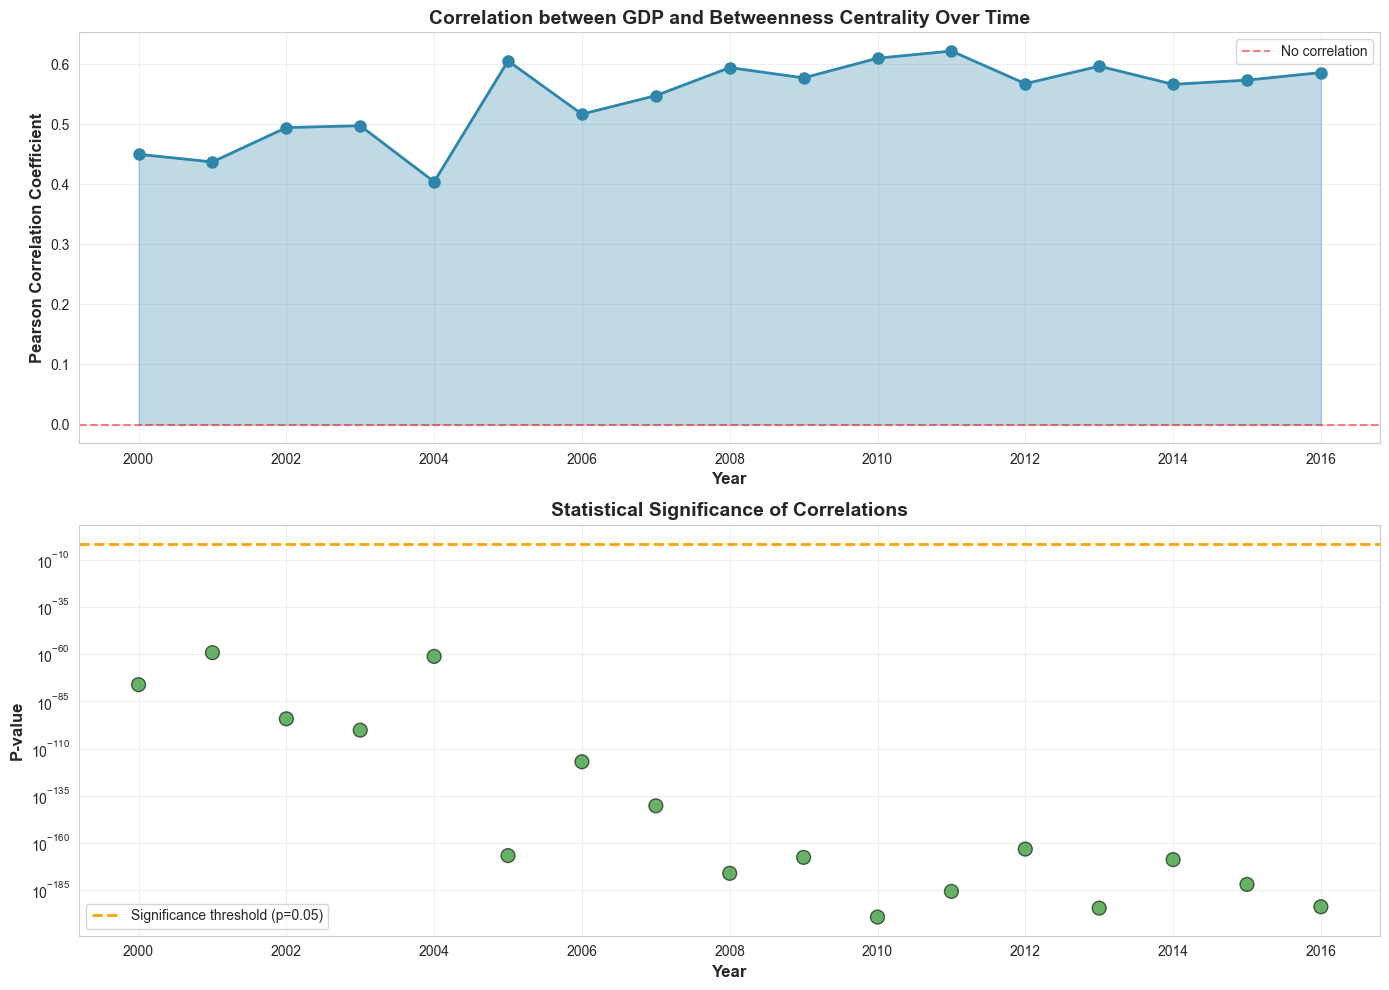

Plot saved as 'correlation_gdp_betweenness_over_time.png'


In [15]:
# Visualize the correlation coefficients over time
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Correlation coefficient over time
ax1.plot(correlation_results['year'], correlation_results['correlation'], 
         marker='o', linewidth=2, markersize=8, color='#2E86AB')
ax1.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='No correlation')
ax1.fill_between(correlation_results['year'], correlation_results['correlation'], 
                 0, alpha=0.3, color='#2E86AB')
ax1.set_xlabel('Year', fontsize=12, fontweight='bold')
ax1.set_ylabel('Pearson Correlation Coefficient', fontsize=12, fontweight='bold')
ax1.set_title('Correlation between GDP and Betweenness Centrality Over Time', 
              fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot 2: P-values over time with significance threshold
colors = ['green' if p < 0.05 else 'red' for p in correlation_results['p_value']]
ax2.scatter(correlation_results['year'], correlation_results['p_value'], 
           c=colors, s=100, alpha=0.6, edgecolors='black')
ax2.axhline(y=0.05, color='orange', linestyle='--', linewidth=2, 
           label='Significance threshold (p=0.05)')
ax2.set_xlabel('Year', fontsize=12, fontweight='bold')
ax2.set_ylabel('P-value', fontsize=12, fontweight='bold')
ax2.set_title('Statistical Significance of Correlations', fontsize=14, fontweight='bold')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.savefig('correlation_gdp_betweenness_over_time.png', dpi=300, bbox_inches='tight')
plt.show()

print("Plot saved as 'correlation_gdp_betweenness_over_time.png'")

In [16]:
# Summary statistics
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)
print(f"\nMean correlation coefficient: {correlation_results['correlation'].mean():.4f}")
print(f"Median correlation coefficient: {correlation_results['correlation'].median():.4f}")
print(f"Standard deviation: {correlation_results['correlation'].std():.4f}")
print(f"Min correlation: {correlation_results['correlation'].min():.4f} (Year: {correlation_results.loc[correlation_results['correlation'].idxmin(), 'year']:.0f})")
print(f"Max correlation: {correlation_results['correlation'].max():.4f} (Year: {correlation_results.loc[correlation_results['correlation'].idxmax(), 'year']:.0f})")
print(f"\nSignificant correlations (p < 0.05): {(correlation_results['p_value'] < 0.05).sum()} out of {len(correlation_results)} years")
print(f"Percentage significant: {(correlation_results['p_value'] < 0.05).sum() / len(correlation_results) * 100:.1f}%")


SUMMARY STATISTICS

Mean correlation coefficient: 0.5441
Median correlation coefficient: 0.5677
Standard deviation: 0.0659
Min correlation: 0.4043 (Year: 2004)
Max correlation: 0.6221 (Year: 2011)

Significant correlations (p < 0.05): 17 out of 17 years
Percentage significant: 100.0%


# Comprehensive Pearson Correlation Table: Network Metrics vs GDP

Similar to the reference table showing correlations between network indicators and port capacity, we'll create a table showing correlations between various network metrics and GDP across different categories.

In [17]:
# Define network indicators to analyze
network_indicators = {
    'degree': 'Degree',
    'clustering': 'Clustering',
    'betweenness': 'Betweenness',
    'closeness': 'Closeness', 
    'eigenvector': 'Eigenvector',
    'pagerank': 'PageRank',
    'local_efficiency': 'Local Efficiency',
    'participation_coefficient': 'Participation Coef.',
    'within_module_degree': 'Within-Module Degree'
}

# Function to calculate correlation with significance
def calculate_correlation(data, network_metric, econ_metric='gdp_regional_10k'):
    """Calculate Pearson correlation between network metric and economic metric"""
    valid_data = data.dropna(subset=[network_metric, econ_metric])
    
    if len(valid_data) < 2:
        return np.nan, np.nan, 0
    
    corr, p_val = pearsonr(valid_data[network_metric], valid_data[econ_metric])
    return corr, p_val, len(valid_data)

# Function to format correlation with significance markers
def format_correlation(corr, p_val):
    """Format correlation coefficient with significance markers"""
    if np.isnan(corr):
        return '--'
    
    if p_val < 0.001:
        sig_marker = '**'
    elif p_val < 0.01:
        sig_marker = '*'
    else:
        sig_marker = ''
    
    return f"{corr:.2f}{sig_marker}"

print("Setup complete. Functions defined for correlation analysis.")

Setup complete. Functions defined for correlation analysis.


## Summary of Analysis

This notebook performs comprehensive Pearson correlation analysis between network metrics and GDP, similar to the reference table format.

### Generated Files

**Main Correlation Tables:**
1. **correlation_table_network_gdp_formatted.csv** - Table with significance markers (\*\*, \*)
2. **correlation_table_network_gdp_values.csv** - Raw correlation coefficients
3. **correlation_table_network_gdp_pvalues.csv** - P-values for statistical significance
4. **correlation_table_network_gdp_samples.csv** - Sample sizes for each correlation

**Year-by-Year Analysis:**
5. **correlation_network_gdp_by_year.csv** - Correlations for each year and indicator
6. **pearson_correlation_gdp_betweenness.csv** - Original betweenness-only analysis

**Visualizations:**
7. **correlation_heatmap_network_gdp.png** - Heatmap of correlations across categories
8. **correlation_temporal_evolution_all_metrics.png** - Time series showing how correlations evolve
9. **correlation_gdp_betweenness_over_time.png** - Betweenness correlation over time (original analysis)

**Publication-Ready:**
10. **correlation_table_latex.txt** - LaTeX code ready to paste into papers

### Key Results

The analysis calculates correlations across multiple dimensions:
- **Overall**: All data combined
- **By Granularity**: County, Prefecture, Province levels
- **By Time Period**: 2000-2005, 2006-2010, 2011-2016

All correlations include significance testing with markers for p < 0.001 (\*\*) and p < 0.01 (\*).

In [18]:
# Calculate correlations for different categories
print("Calculating correlations across different categories...")

categories = {}

# Category 1: Overall (all data combined)
print("  - Overall")
categories['Overall'] = {}
for metric_key, metric_name in network_indicators.items():
    corr, p_val, n = calculate_correlation(merged_data, metric_key)
    categories['Overall'][metric_name] = (corr, p_val, n)

# Category 2: By Granularity (county, prefecture, province)
for granularity in ['county', 'prefecture', 'province']:
    print(f"  - {granularity.capitalize()}")
    gran_data = merged_data[merged_data['granularity'] == granularity]
    if len(gran_data) > 0:
        categories[granularity.capitalize()] = {}
        for metric_key, metric_name in network_indicators.items():
            corr, p_val, n = calculate_correlation(gran_data, metric_key)
            categories[granularity.capitalize()][metric_name] = (corr, p_val, n)

# Category 3: By Time Periods
time_periods = {
    '2000-2005': (2000, 2005),
    '2006-2010': (2006, 2010),
    '2011-2016': (2011, 2016)
}

for period_name, (start_year, end_year) in time_periods.items():
    print(f"  - {period_name}")
    period_data = merged_data[(merged_data['year'] >= start_year) & 
                              (merged_data['year'] <= end_year)]
    if len(period_data) > 0:
        categories[period_name] = {}
        for metric_key, metric_name in network_indicators.items():
            corr, p_val, n = calculate_correlation(period_data, metric_key)
            categories[period_name][metric_name] = (corr, p_val, n)

print(f"\nCalculated correlations for {len(categories)} categories.")

Calculating correlations across different categories...
  - Overall
  - County
  - Prefecture
  - Province
  - 2000-2005
  - 2006-2010
  - 2011-2016

Calculated correlations for 5 categories.


In [19]:
# Create correlation tables

# Table 1: Formatted with significance markers
correlation_table = pd.DataFrame(index=list(network_indicators.values()))
for category_name, metrics_dict in categories.items():
    correlation_table[category_name] = [
        format_correlation(metrics_dict.get(metric, (np.nan, np.nan, 0))[0],
                          metrics_dict.get(metric, (np.nan, np.nan, 0))[1])
        for metric in network_indicators.values()
    ]

# Table 2: Raw correlation values
correlation_values = pd.DataFrame(index=list(network_indicators.values()))
for category_name, metrics_dict in categories.items():
    correlation_values[category_name] = [
        metrics_dict.get(metric, (np.nan, np.nan, 0))[0]
        for metric in network_indicators.values()
    ]

# Table 3: P-values
p_values_table = pd.DataFrame(index=list(network_indicators.values()))
for category_name, metrics_dict in categories.items():
    p_values_table[category_name] = [
        metrics_dict.get(metric, (np.nan, np.nan, 0))[1]
        for metric in network_indicators.values()
    ]

# Table 4: Sample sizes
sample_sizes = pd.DataFrame(index=list(network_indicators.values()))
for category_name, metrics_dict in categories.items():
    sample_sizes[category_name] = [
        metrics_dict.get(metric, (np.nan, np.nan, 0))[2]
        for metric in network_indicators.values()
    ]

print("Correlation tables created successfully!")

Correlation tables created successfully!


In [20]:
# Display the main correlation table
print("\n" + "="*100)
print("TABLE: Pearson Correlation Coefficients between Network Indicators and GDP")
print("="*100)
print("\nNote: **p < 0.001, *p < 0.01")
print("\n" + correlation_table.to_string())
print("\n" + "="*100)


TABLE: Pearson Correlation Coefficients between Network Indicators and GDP

Note: **p < 0.001, *p < 0.01

                     Overall  County 2000-2005 2006-2010 2011-2016
Degree                0.57**  0.57**    0.49**    0.55**    0.56**
Clustering              0.00    0.00     -0.02    -0.03*   -0.04**
Betweenness           0.42**  0.42**    0.45**    0.55**    0.58**
Closeness             0.40**  0.40**    0.23**    0.31**    0.39**
Eigenvector           0.23**  0.23**    0.28**    0.34**    0.28**
PageRank              0.46**  0.46**    0.49**    0.54**    0.56**
Local Efficiency      0.10**  0.10**     -0.01      0.01    0.04**
Participation Coef.   0.21**  0.21**    0.23**    0.19**    0.24**
Within-Module Degree  0.38**  0.38**    0.39**    0.42**    0.47**



In [21]:
# Save all tables to CSV
correlation_table.to_csv('correlation_table_network_gdp_formatted.csv')
correlation_values.to_csv('correlation_table_network_gdp_values.csv')
p_values_table.to_csv('correlation_table_network_gdp_pvalues.csv')
sample_sizes.to_csv('correlation_table_network_gdp_samples.csv')

print("Tables saved:")
print("  - correlation_table_network_gdp_formatted.csv (with significance markers)")
print("  - correlation_table_network_gdp_values.csv (raw values)")
print("  - correlation_table_network_gdp_pvalues.csv (p-values)")
print("  - correlation_table_network_gdp_samples.csv (sample sizes)")

Tables saved:
  - correlation_table_network_gdp_formatted.csv (with significance markers)
  - correlation_table_network_gdp_values.csv (raw values)
  - correlation_table_network_gdp_pvalues.csv (p-values)
  - correlation_table_network_gdp_samples.csv (sample sizes)


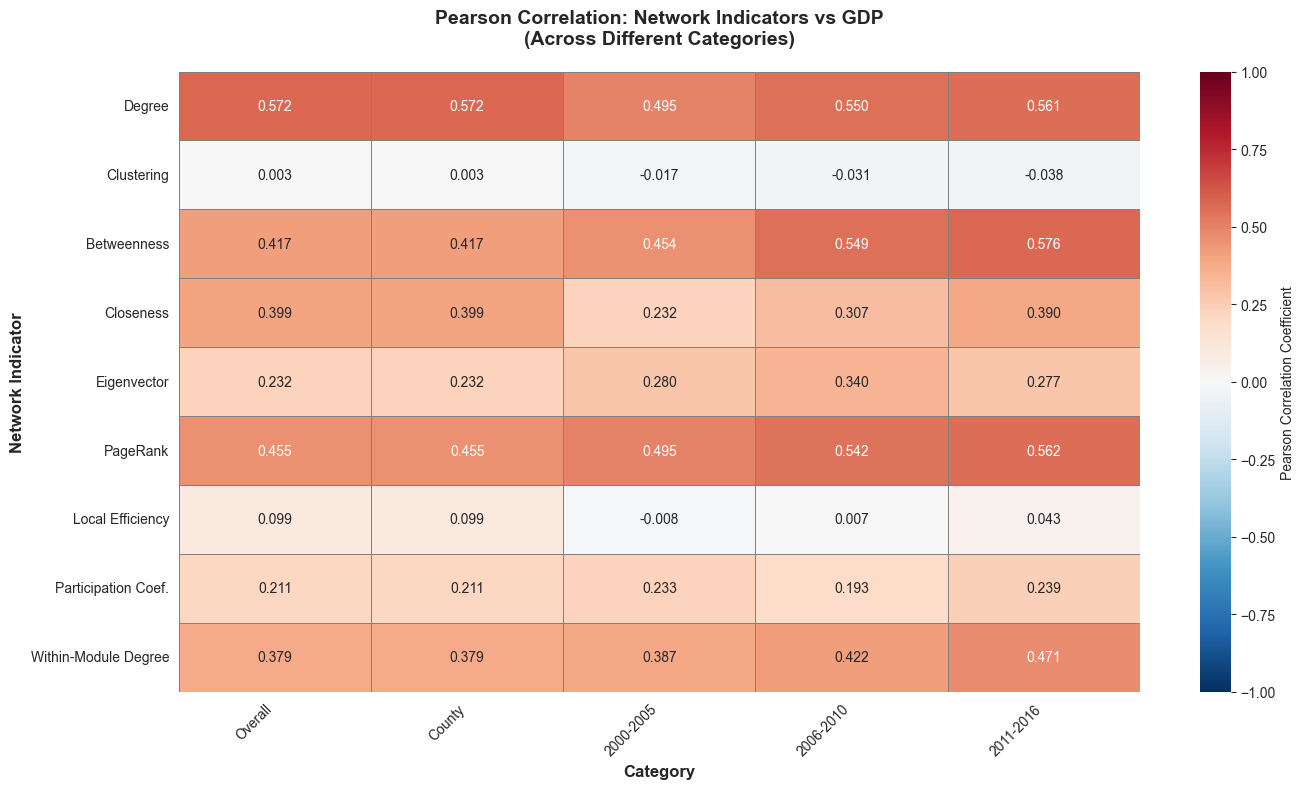

Heatmap saved as 'correlation_heatmap_network_gdp.png'


In [22]:
# Create heatmap visualization
fig, ax = plt.subplots(figsize=(14, 8))

sns.heatmap(correlation_values, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1,
            cbar_kws={'label': 'Pearson Correlation Coefficient'},
            linewidths=0.5, linecolor='gray', ax=ax)

plt.title('Pearson Correlation: Network Indicators vs GDP\n(Across Different Categories)',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Category', fontsize=12, fontweight='bold')
plt.ylabel('Network Indicator', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig('correlation_heatmap_network_gdp.png', dpi=300, bbox_inches='tight')
plt.show()

print("Heatmap saved as 'correlation_heatmap_network_gdp.png'")

In [23]:
# Year-by-year analysis for all network indicators
print("Performing year-by-year analysis...")

yearly_correlations = []
available_years = sorted([y for y in merged_data['year'].unique() if not np.isnan(y)])

for year in available_years:
    year_data = merged_data[merged_data['year'] == year]
    year_results = {'year': int(year)}
    
    for metric_key, metric_name in network_indicators.items():
        corr, p_val, n = calculate_correlation(year_data, metric_key)
        year_results[f'{metric_name}_corr'] = corr
        year_results[f'{metric_name}_pval'] = p_val
        year_results[f'{metric_name}_n'] = n
    
    yearly_correlations.append(year_results)

# Create DataFrame
yearly_corr_df = pd.DataFrame(yearly_correlations)

# Save to CSV
yearly_corr_df.to_csv('correlation_network_gdp_by_year.csv', index=False)

print(f"Year-by-year analysis complete for {len(available_years)} years!")
print("Results saved to 'correlation_network_gdp_by_year.csv'")
print("\nSample (first 5 years):")
print(yearly_corr_df[['year', 'Degree_corr', 'Betweenness_corr', 'PageRank_corr']].head())

Performing year-by-year analysis...
Year-by-year analysis complete for 17 years!
Results saved to 'correlation_network_gdp_by_year.csv'

Sample (first 5 years):
   year  Degree_corr  Betweenness_corr  PageRank_corr
0  2000     0.475163          0.450071       0.479524
1  2001     0.487078          0.437374       0.480140
2  2002     0.522440          0.494537       0.519016
3  2003     0.518421          0.497666       0.520661
4  2004     0.472539          0.404294       0.474659


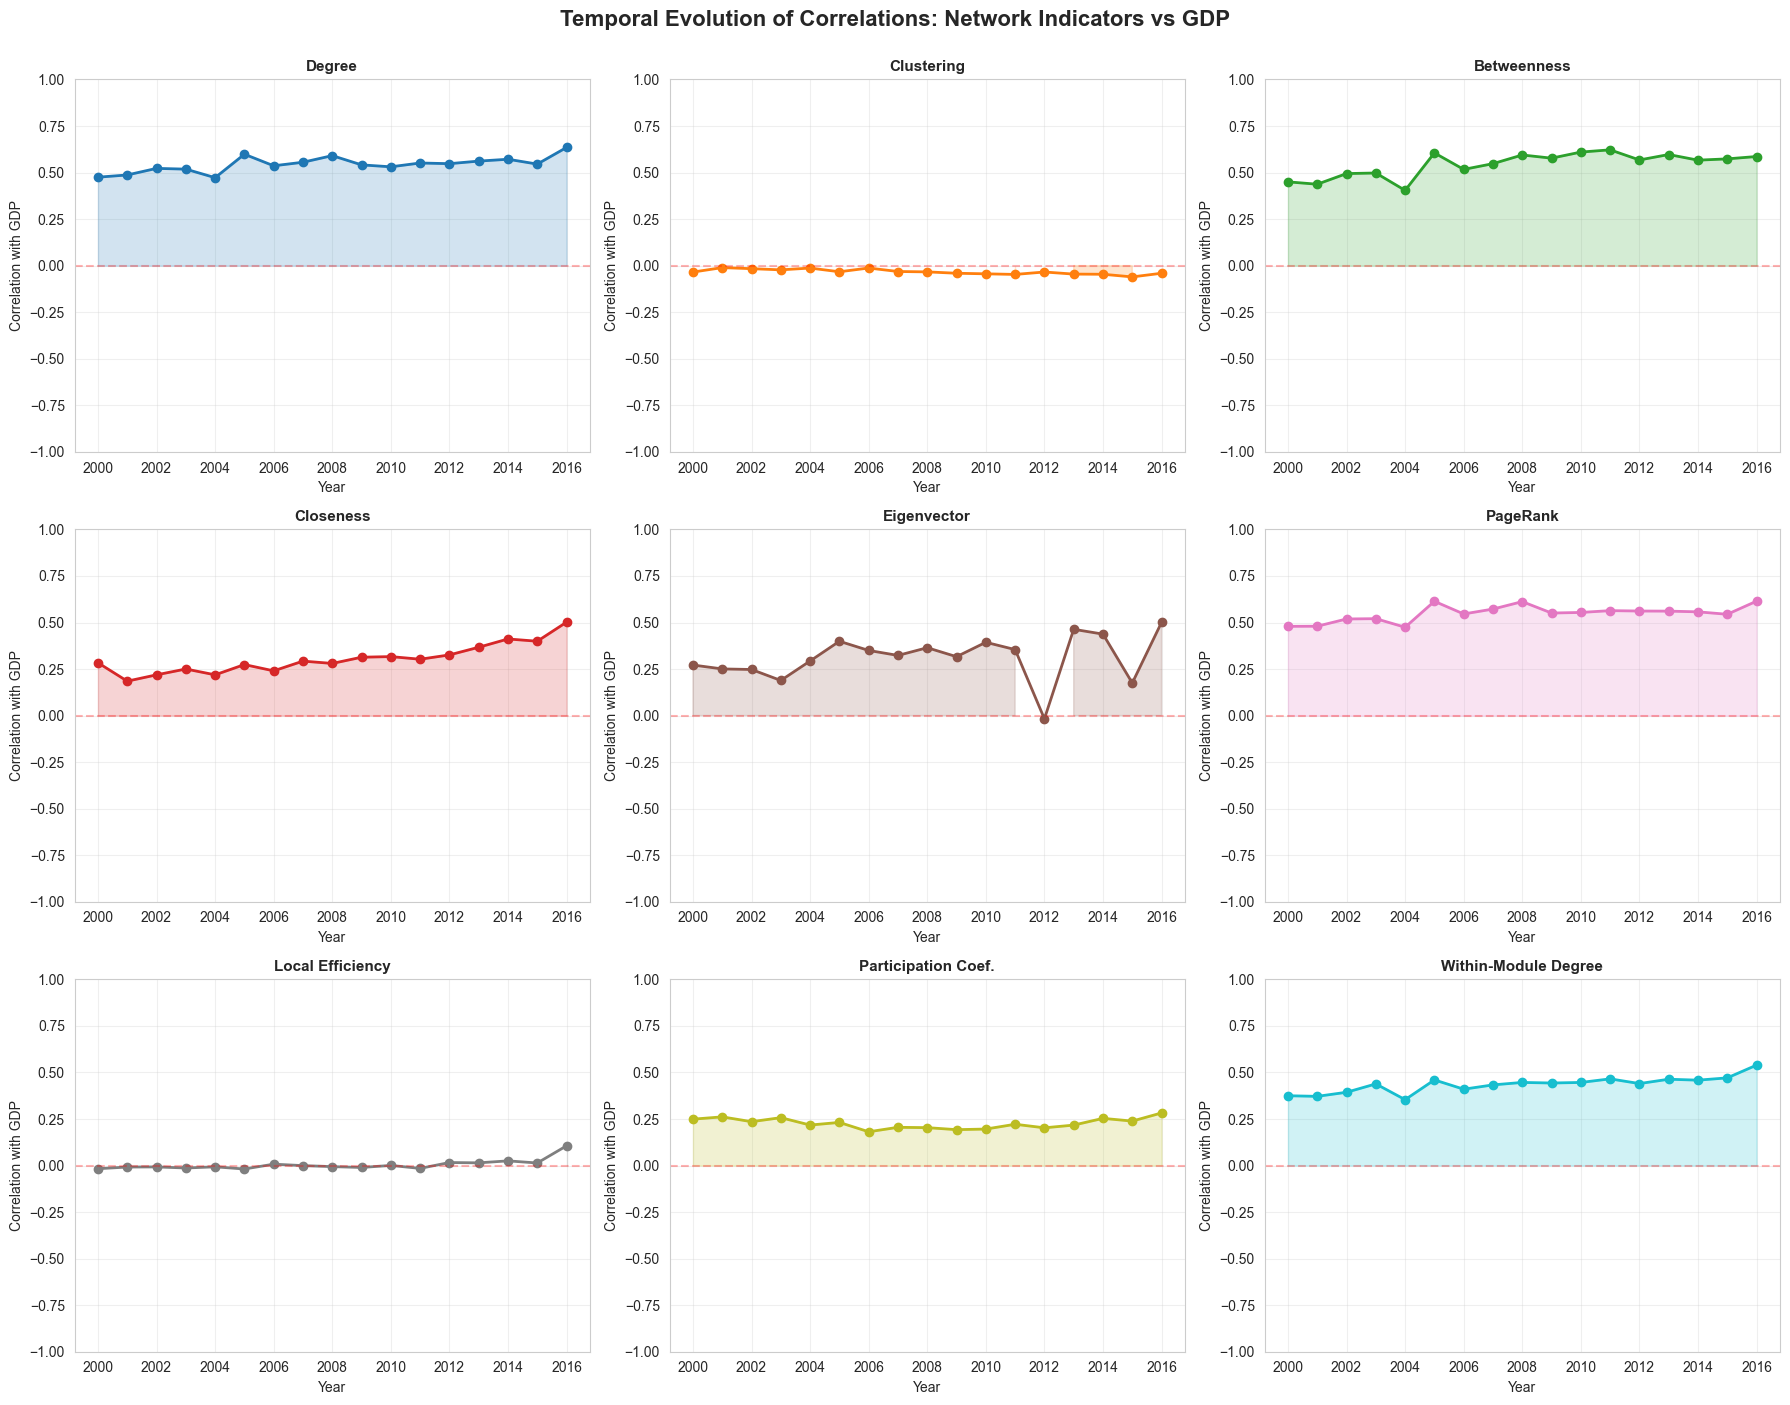

Temporal evolution plot saved as 'correlation_temporal_evolution_all_metrics.png'


In [24]:
# Visualize temporal evolution of correlations for all network metrics
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

colors = plt.cm.tab10(np.linspace(0, 1, len(network_indicators)))

for idx, (metric_key, metric_name) in enumerate(network_indicators.items()):
    ax = axes[idx]
    
    # Extract correlation values for this metric
    corr_col = f'{metric_name}_corr'
    pval_col = f'{metric_name}_pval'
    
    years = yearly_corr_df['year'].values
    correlations = yearly_corr_df[corr_col].values
    p_values_yearly = yearly_corr_df[pval_col].values
    
    # Plot correlation over time
    ax.plot(years, correlations, marker='o', linewidth=2, 
            markersize=6, color=colors[idx], label=metric_name)
    
    # Add significance shading
    significant = p_values_yearly < 0.05
    ax.fill_between(years, correlations, 0, 
                     where=significant, alpha=0.2, color=colors[idx])
    
    # Add reference line at 0
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.3)
    
    # Formatting
    ax.set_xlabel('Year', fontsize=10)
    ax.set_ylabel('Correlation with GDP', fontsize=10)
    ax.set_title(metric_name, fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-1, 1)

plt.suptitle('Temporal Evolution of Correlations: Network Indicators vs GDP', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()

plt.savefig('correlation_temporal_evolution_all_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

print("Temporal evolution plot saved as 'correlation_temporal_evolution_all_metrics.png'")

In [25]:
# Generate LaTeX table for publication
latex_code = "\\begin{table}[htbp]\n"
latex_code += "\\centering\n"
latex_code += "\\caption{Pearson correlation coefficients between network indicators and GDP}\n"
latex_code += "\\begin{tabular}{l" + "c" * len(correlation_table.columns) + "}\n"
latex_code += "\\hline\n"

# Header
latex_code += "Network Indicator & " + " & ".join(correlation_table.columns) + " \\\\\n"
latex_code += "\\hline\n"

# Data rows
for idx, row in correlation_table.iterrows():
    latex_code += idx + " & " + " & ".join([str(val) for val in row]) + " \\\\\n"

latex_code += "\\hline\n"
latex_code += "\\end{tabular}\n"
latex_code += "\\\\[0.2cm]\n"
latex_code += "\\footnotesize{Note: **p $<$ 0.001, *p $<$ 0.01}\n"
latex_code += "\\end{table}\n"

# Save to file
with open('correlation_table_latex.txt', 'w') as f:
    f.write(latex_code)

print("LaTeX table generated and saved to 'correlation_table_latex.txt'")

LaTeX table generated and saved to 'correlation_table_latex.txt'


## Summary of Generated Files

This analysis has generated the following files:

### Main Correlation Tables (Similar to Reference Table):
1. **correlation_table_network_gdp_formatted.csv** - Main table with significance markers (**, *)
2. **correlation_table_network_gdp_values.csv** - Raw correlation coefficients
3. **correlation_table_network_gdp_pvalues.csv** - P-values for all correlations
4. **correlation_table_network_gdp_samples.csv** - Sample sizes for each correlation

### Year-by-Year Analysis:
5. **correlation_network_gdp_by_year.csv** - Correlations for each year and each indicator
6. **pearson_correlation_gdp_betweenness.csv** - Original betweenness-only analysis

### Visualizations:
7. **correlation_heatmap_network_gdp.png** - Heatmap of correlations across categories
8. **correlation_temporal_evolution_all_metrics.png** - Time series of all correlations
9. **correlation_gdp_betweenness_over_time.png** - Betweenness correlation over time

### Publication-Ready:
10. **correlation_table_latex.txt** - LaTeX code for table (ready for papers)